In [17]:
# !pip install pandas numpy matplotlib seaborn scipy
###########DATA PROCESSING AND ANALYSIS#################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy as sp
import os
from datetime import datetime
############REFORMAT DATA########################

data_directory = 'video_data/aggression_data/'
data_dates = os.listdir(data_directory)
log_folders = [os.path.join(data_directory, date,'logs') for date in data_dates]
log_files = []

for folder in log_folders:
    files = os.listdir(folder)
    log_files += [os.path.join(folder, file) for file in files if file.endswith('.csv')]

df_list = []
mouse_ids = [log_files[0][53:56] for file in log_files]

for file in log_files:
    df = pd.read_csv(file)
    df['mouse_id'] = [file[53:56] for i in range(len(df))]
    df_list.append(df)
data = pd.concat(df_list, ignore_index=True)
data.tail()

date_format = '%Y-%m-%d_%H:%M:%S.%f'
list_starttimes = list(data['start_times'])
list_attackstoptimes = list(data['attack_stop_times'])
data['time_to_stop'] = [(datetime.strptime(a,date_format) - datetime.strptime(s,date_format)).total_seconds() for a,s in zip(list_attackstoptimes,list_starttimes)] 
data.tail()

,Unnamed: 0,start_times,attack_stop_times,end_times,on_status,mouse_id,time_to_stop
105,1,2025-11-14_15:14:19.929692,2025-11-14_15:14:22.388590,2025-11-14_15:14:29.931843,False,122,2.458898
106,0,2025-11-13_15:19:41.989288,2025-11-13_15:19:44.316369,2025-11-13_15:19:52.009394,True,122,2.327081
107,0,2025-11-13_12:53:51.545813,2025-11-13_12:53:53.996035,2025-11-13_12:54:01.555142,False,122,2.450222
108,1,2025-11-13_12:55:11.260717,2025-11-13_12:55:12.236302,2025-11-13_12:55:21.271127,False,122,0.975585
109,0,2025-11-13_16:23:19.155333,2025-11-13_16:23:22.366819,2025-11-13_16:23:29.174810,True,123,3.211486


In [33]:
data.rename(columns={"Unnamed: 0": "attack_number"},inplace=True)
# data['attack_number']
data.head()

,attack_number,start_times,attack_stop_times,end_times,on_status,mouse_id,time_to_stop
0,0,2025-11-04_17:07:46.104566,2025-11-04_17:07:47.292556,2025-11-04_17:07:56.127299,True,122,1.187990
1,1,2025-11-04_17:16:16.614357,2025-11-04_17:16:21.250115,2025-11-04_17:16:26.632187,False,122,4.635758
2,2,2025-11-04_17:18:22.033189,2025-11-04_17:18:36.384029,2025-11-04_17:18:32.052979,True,122,14.350840
3,3,2025-11-04_17:18:45.356480,2025-11-04_17:18:51.495103,2025-11-04_17:18:55.378484,True,122,6.138623
4,0,2025-11-04_15:29:43.530092,2025-11-04_15:29:46.941576,2025-11-04_15:29:53.555022,True,122,3.411484


In [2]:
#filter data frames into CTRL and light on
light_on = data[data['on_status'] == True]
light_off = data[data['on_status'] == False]

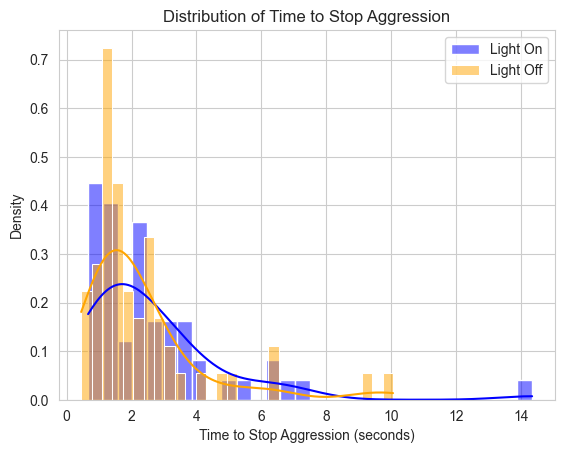

In [3]:
#Plotting
sns.set_style("whitegrid")
sns.histplot(light_on['time_to_stop'], color='blue', label='Light On', kde=True, stat='density', bins=30)
sns.histplot(light_off['time_to_stop'], color='orange', label='Light Off', kde=True, stat='density', bins=30)
plt.xlabel('Time to Stop Aggression (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time to Stop Aggression')
plt.legend()
plt.show()


<Axes: xlabel='on_status', ylabel='time_to_stop'>

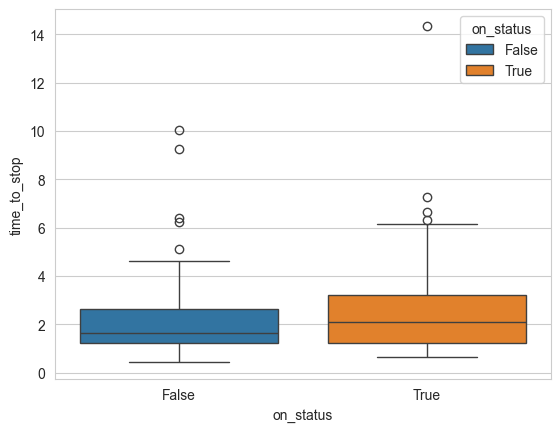

In [4]:
sns.boxplot(x='on_status', y = 'time_to_stop',data=data,hue='on_status')

In [5]:
sp.stats.ranksums(light_on['time_to_stop'], light_off['time_to_stop'])

RanksumsResult(statistic=np.float64(0.9566613377789003), pvalue=np.float64(0.3387382183887584))

<Axes: xlabel='on_status', ylabel='time_to_stop'>

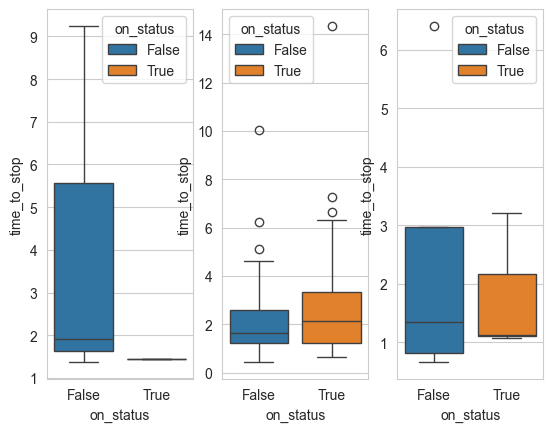

In [25]:
###per mouse analysis###
fig, axs = plt.subplots(ncols=3)
sns.boxplot(x='on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '121'],hue='on_status', ax=axs[0])
sns.boxplot(x='on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '122'],hue='on_status', ax=axs[1])
sns.boxplot(x='on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '123'],hue='on_status', ax=axs[2])


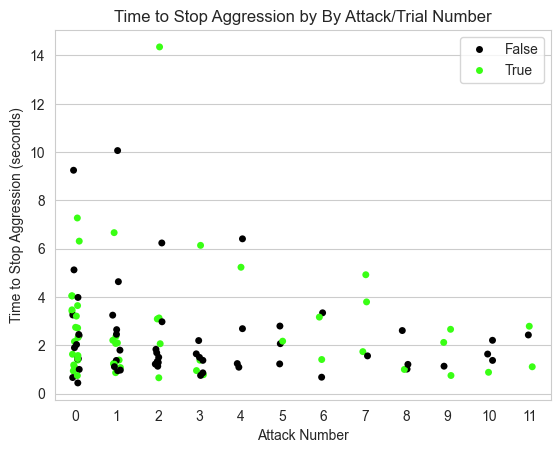

In [40]:
sns.set_style("whitegrid")
sns.stripplot(x='attack_number', y = 'time_to_stop',data=data, jitter=True, hue='on_status',palette={True: '#39FF14', False: 'black'})
plt.xlabel('Attack Number')
plt.ylabel('Time to Stop Aggression (seconds)')
plt.title('Time to Stop Aggression by By Attack/Trial Number')
plt.legend()
plt.show()


In [ ]:
[1,0] + [np.nan]

In [10]:
#latency (time to NEXT attack after stim on/off)
#clear variable
data_iti = None
df_list = []
for file in log_files:
    df = pd.read_csv(file)
    iti = []
    list_starts = df['start_times']
    for i in range(len(df)-1):
        # print((datetime.strptime(list_starts[i+1],date_format) - datetime.strptime(list_starts[i],date_format)).total_seconds())
        iti.append((datetime.strptime(list_starts[i+1],date_format) - datetime.strptime(list_starts[i],date_format)).total_seconds())
    print(iti)
    df['iti'] = iti + [np.nan]
    df_list.append(df)
data_iti = pd.concat(df_list, ignore_index=True).dropna()
data_iti.tail()

[]
[]
[510.509791, 125.418832, 23.323291]
[]
[27.837572, 22.124358, 30.856134, 96.954919, 18.852693, 128.368484, 23.225429, 93.96249, 129.797787, 286.17653]
[60.61538, 417.474267, 118.682173]
[948.377031]
[]
[171.977281, 654.551145]
[]
[]
[]
[140.261034, 109.673302]
[]
[]
[445.085675]
[]
[363.622662]
[]
[]
[]
[486.950229, 62.082681]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[12.245011, 136.309558, 69.838294]
[14.615479, 16.695553, 135.949878, 94.099511, 50.52106, 52.033199, 36.503777, 223.977597, 14.249905, 76.031521, 191.931782]
[44.529393, 59.387747, 20.579678, 61.907505, 150.13425, 64.682109, 14.593901, 49.864525, 114.642068, 208.452111, 87.648613]
[]
[]
[]
[]
[]
[]
[51.511946, 128.55095, 100.699631]
[]
[53.71622]
[]
[]
[19.986247, 170.202336]
[19.199056, 37.507887, 42.510281, 70.415949, 204.729159, 42.337905, 67.693271, 248.807618, 30.928829, 40.029575, 219.94154]
[]
[338.133613, 16.478918, 27.644321, 138.642089]
[288.869748, 313.76787, 20.184258]
[]
[]
[31.890956]
[]
[59.324603]
[]
[]
[79.714904

,Unnamed: 0,start_times,attack_stop_times,end_times,on_status,iti
121,1,2025-11-14_14:28:52.622585,2025-11-14_14:28:53.740652,2025-11-14_14:29:02.647632,False,313.767870
122,2,2025-11-14_14:34:06.390455,2025-11-14_14:34:07.048653,2025-11-14_14:34:16.394953,True,20.184258
126,0,2025-11-14_14:57:04.370036,2025-11-14_14:57:10.683587,2025-11-14_14:57:14.387087,True,31.890956
129,0,2025-11-14_15:13:20.605089,2025-11-14_15:13:21.354011,2025-11-14_15:13:30.620847,True,59.324603
133,0,2025-11-13_12:53:51.545813,2025-11-13_12:53:53.996035,2025-11-13_12:54:01.555142,False,79.714904


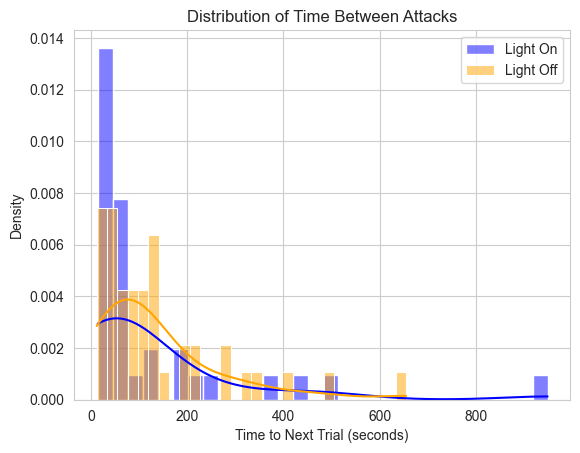

In [16]:
#Plotting
light_on_iti = data_iti[data_iti['on_status'] == True]
light_off_iti = data_iti[data_iti['on_status'] == False]
sns.set_style("whitegrid")
sns.histplot(light_on_iti['iti'], color='blue', label='Light On', kde=True, stat='density', bins=30)
sns.histplot(light_off_iti['iti'], color='orange', label='Light Off', kde=True, stat='density', bins=30)
plt.xlabel('Time to Next Trial (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Between Attacks')
plt.legend()
plt.show()

<Axes: xlabel='on_status', ylabel='iti'>

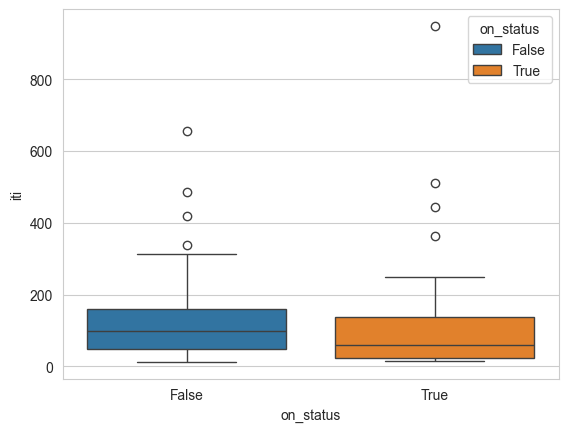

In [14]:
sns.boxplot(x='on_status', y = 'iti',data=data_iti,hue='on_status')

In [15]:
sp.stats.ranksums(light_on_iti['iti'], light_off_iti['iti'])

RanksumsResult(statistic=np.float64(-1.6366549857180974), pvalue=np.float64(0.10170257953884747))

In [ ]:
#total number of attacks per session